In [6]:
# Steel model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
from scipy.optimize import OptimizeWarning
warnings.simplefilter('ignore', OptimizeWarning)

from imagematerials.rest_of.resource_model import ResourceModel
from imagematerials.rest_of.const import (all_regions_list_class, 
                                          models_output_dict)

In [ ]:
# Steel
steel = ResourceModel(resource_group = 'metals', resource = 'steel', 
                       image_mat_available = True, start_year = 1971,
                          scenario = 'SSP2_M_CP',
                       convert_image=True, end_year = 2012, convert_to_tons = 1/1000_000, 
                       trade_data=True)


   class_1 = ['class_ 1'] 

   high = ['class_ 19', 'class_ 23']

   china = ['class_ 20']

   low = ['class_ 2', 'class_ 11' , 'class_ 12', 'class_ 13', 'class_ 24']

   very_low = ['class_ 4', 'class_ 8', 'class_ 22', 'class_ 25']

   very_low_2 = ["class_ 3", "class_ 5", "class_ 6", "class_ 7", "class_ 9", "class_ 17", "class_ 18", "class_ 21", "class_ 26"]

   # trajectory not to forseen, will be fitted with global regression
   spreaded = ['class_ 10', 'class_ 14', 'class_ 15', 'class_ 16']

   exclude = spreaded + very_low_2


# what is in rest will not be fitted because of outliers - will follow global projections       
rest = all_regions_list_class[:-1]
rest = [r for r in rest if r not in (low+class_1+high+very_low+very_low_2)]

   # for these models a regression will be made
   # all reginos that are not in the high, medium, low will be fitted with the global regression
   steel_grouping = {'all' : all_regions_list_class[:-1],
                     'class_ 1': class_1,
                     'high': high,
                     'china': china,
                     'low': low,
                     'very_low': very_low,
                     'very_low_2': very_low_2,
                  }

#steel_grouping = {'all' : all_regions_list_class[:-1]}
steel.data_grouped_regions(regions_grouping = steel_grouping)

# get drivers for fitting (regions dont need to be summed, regions dict is none)
steel.sum_IMAGE_drivers_regions(regions_dict=None)

steel.match_MAT_data_to_regions_year(match_external_regions=False)
steel.calculate_historic_other_fraction()


In [8]:
rest

['class_ 10', 'class_ 14', 'class_ 15', 'class_ 16']

In [9]:
# neg_classes = ['class_ 4', 'class_ 8', 'class_ 9', 'class_ 22', 'class_ 25', 'class_ 26']
# steel.historic_other_fraction_consumption[neg_classes] = steel.historic_consumption_data[neg_classes]

# deal with single negative numbers by removing them from dataset
steel.historic_other_fraction_consumption[steel.historic_other_fraction_consumption < 0] = np.nan

# Fit models 
steel.calculate_regressors(steel.historic_other_fraction_consumption)

In [10]:
bounds = {
'all': ([0, 0, 0], [10, 10, 10]),
'very_low': ([0, 0, 0], [10, 10, 10]),
'very_low_2': ([0, 0, 0], [10, 10, 10]),
'class_1': ([0, 0, 0], [10, 10, 10]),
'high': ([0, 0, 0], [0.5, 10, 10]),
'low': ([0, 0, 0], [10, 10, 10])
}

# enforce that for all groups gompertz model is selected as best fit
steel.fit_models(best_rmse_models={'all' : 'gompertz model',
                                   'very_low': 'gompertz model',
                                   'very_low_2': 'gompertz model',
                                'class_1': 'gompertz model',
                                'high': 'gompertz model',
                                'low': 'gompertz model'},
                                bounds=bounds)


C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return a * np.exp(-((logX - b) ** 2) / (2 * c ** 2)) + d
C:\Users\Arp00003\Coding\image-materials\imagematerials\rest_of\regression_models_classes.py:375: RuntimeWarning: divide by zero encountered in divide
  return 

In [11]:
# project based on best model
steel.project_on_total(all_regions_list_class[:-1])
steel.smooth_out_interpolation_all(10, 2012)
steel.adjust_alpha_and_project(all_regions_list_class[:-1], 
                            start_year_adjust=2025, 
                            end_year_adjust=2100, 
                            min_alpha=None)

steel.remove_regions_with_no_good_fit_from_region_model_match(exclude)

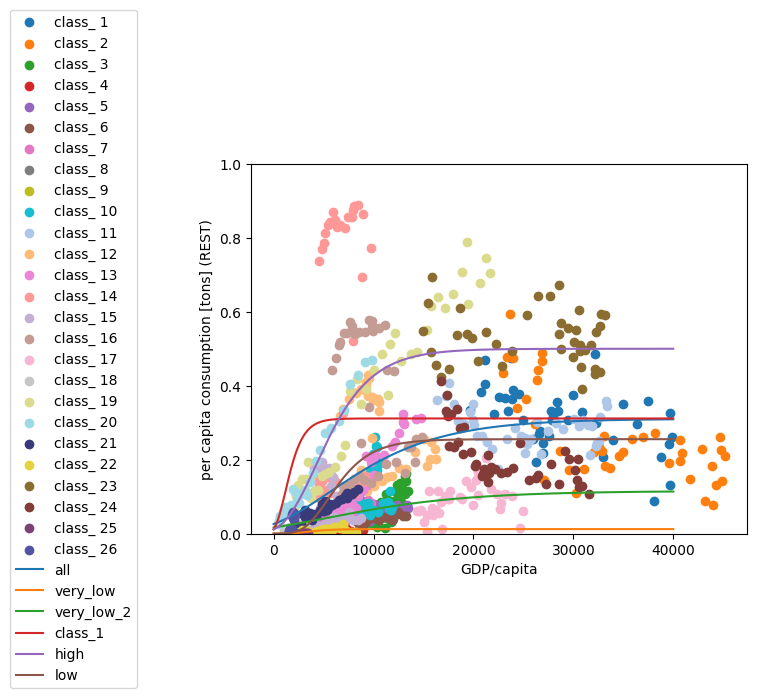

In [12]:
# Plot regression with GDP/cap on x axis and cons/cap on y axis only for years that were fitted

colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', "#EB85D5", '#ff9896', '#c5b0d5',
    '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d', '#9edae5',
    '#393b79', "#E4D33D", '#8c6d31', '#843c39', '#7b4173',
    '#5254a3'
]

# Create the mapping dictionary
color_dict = {f"class_ {i+1}": colors[i] for i in range(26)}

fig, ax = plt.subplots()             # Create a figure containing a single Axes.


for region in steel.cons_capita.columns:
    ax.scatter(steel.gdp_pc[region], 
               steel.cons_capita[region], 
               label = region,
               color = color_dict.get(region))
    
for grouping in steel_grouping.keys():
    model = steel.model_groups[grouping][models_output_dict[steel.best_rmse_models[grouping]]]
    ax.plot(model.predict(np.arange(1, 40001).reshape(-1, 1)),
            label = grouping)

ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")

# set ax limits
ax.set_ylim(0, 1)

ax.legend(loc = 'center left', bbox_to_anchor=(-0.5, 0.5))


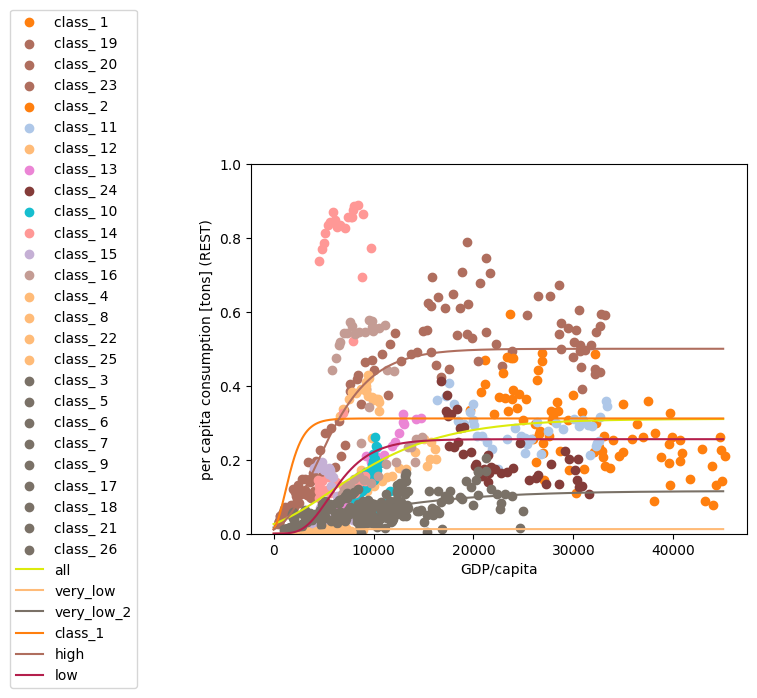

In [13]:
# Grouping of regions for fitting

color_low_gdp = '#1f77b4'
color_low = "#b41f4c"
color_high = "#070707"
color_medium = '#2ca02c'
color_class_1 = '#ff7f0e'
color_high = "#af6e5e"
color_class_20 = "#D33778"
color_class_23 = '#2ca02c'
color_very_low = '#ffbb78'
color_very_low_2 = "#7a7167"

color_dict_fits = {
    'low_gdp': color_low_gdp,
    'very_low': color_very_low,
    'very_low_2': color_very_low_2,
    'class_1': color_class_1,
    'high': color_high,

    'low': color_low,
    'high': color_high,

    'medium': color_medium,
    'all': "#dceb0c",  # Color for all region
}



fig, ax = plt.subplots()             # Create a figure containing a single Axes.
for region in class_1:
    ax.scatter(steel.gdp_pc[region], 
               steel.cons_capita[region], 
               label = region,
               color = color_class_1)

for region in high:
    ax.scatter(steel.gdp_pc[region], 
               steel.cons_capita[region], 
               label = region,
               color = color_high)


for region in low:
    ax.scatter(steel.gdp_pc[region], 
               steel.cons_capita[region], 
               label = region,
               color = color_dict.get(region))
    
for region in rest:
    ax.scatter(steel.gdp_pc[region], 
                steel.cons_capita[region], 
                label = region,
                color = color_dict.get(region))
    
for region in very_low:
    ax.scatter(steel.gdp_pc[region], 
                steel.cons_capita[region], 
                label = region,
                color = color_very_low)

for region in very_low_2:
    ax.scatter(steel.gdp_pc[region], 
                steel.cons_capita[region], 
                label = region,
                color = color_very_low_2)

    
for grouping in steel_grouping.keys():
    model = steel.model_groups[grouping][models_output_dict[steel.best_rmse_models[grouping]]]
    ax.plot(model.predict(np.arange(1, 45000).reshape(-1, 1)),
            label = grouping,
            color = color_dict_fits[grouping])

# set ax limits
ax.set_ylim(0, 1)
ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")
ax.legend(loc = 'center left', bbox_to_anchor=(-0.5, 0.5))




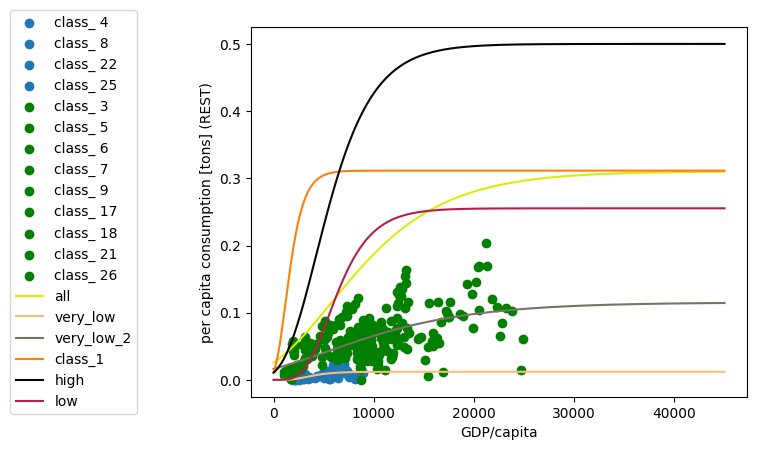

In [28]:
# Grouping of regions for fitting

color_low_gdp = '#1f77b4'
color_low = "#b41f4c"
color_high = "#070707"
color_medium = '#2ca02c'
color_class_1 = '#ff7f0e'
color_class_19 = "#af6e5e"
color_class_20 = "#D33778"
color_class_23 = '#2ca02c'
color_very_low = '#ffbb78'
color_very_low_2 = "#7a7167"

color_dict_fits = {
    'low_gdp': color_low_gdp,
    'very_low': color_very_low,
    'very_low_2': color_very_low_2,
    'class_1': color_class_1,
    'class_19': color_class_19,
    'class_20': color_class_20,
    'class_23': color_class_23,
    'low': color_low,
    'high': color_high,

    'medium': color_medium,
    'all': "#dceb0c",  # Color for all region
}


fig, ax = plt.subplots()             # Create a figure containing a single Axes.





for region in very_low:
    ax.scatter(steel.gdp_pc[region], 
                steel.cons_capita[region], 
                label = region,
                color = color_low_gdp)

# for region in ["class_ 3", "class_ 5", "class_ 6", "class_ 7", "class_ 9", "class_ 17", "class_ 18", "class_ 21", "class_ 26"]:
#     ax.scatter(steel.gdp_pc[region], 
#                 steel.cons_capita[region], 
#                 label = region,
#                 color = color_low)
    
for region in very_low_2:
    ax.scatter(steel.gdp_pc[region], 
                steel.cons_capita[region], 
                label = region,
                color = 'green')
    
for grouping in steel_grouping.keys():
    model = steel.model_groups[grouping][models_output_dict[steel.best_rmse_models[grouping]]]
    ax.plot(model.predict(np.arange(1, 45000).reshape(-1, 1)),
            label = grouping,
            color = color_dict_fits[grouping])

    
# ["class_ 5", "class_ 6", "class_ 7"]



# set ax limits
# ax.set_ylim(0, 1)
ax.set_ylabel("per capita consumption [tons] (REST)")
ax.set_xlabel("GDP/capita")
ax.legend(loc = 'center left', bbox_to_anchor=(-0.5, 0.5))




In [15]:

steel.smooth_out_interpolation_all(10, 2012)

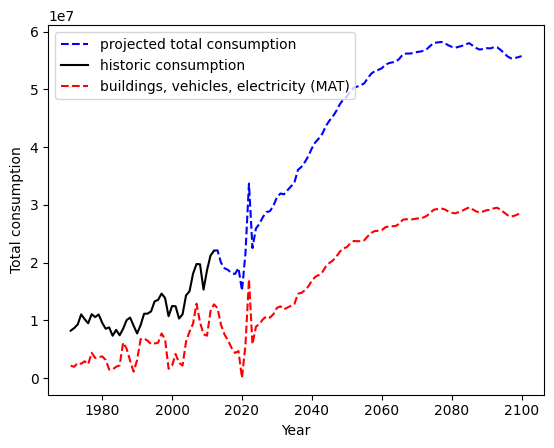

In [16]:
from imagematerials.rest_of.visualization import plot_overview_figure_total_consumption_region
    
plot_overview_figure_total_consumption_region(steel, ["class_ 6"])

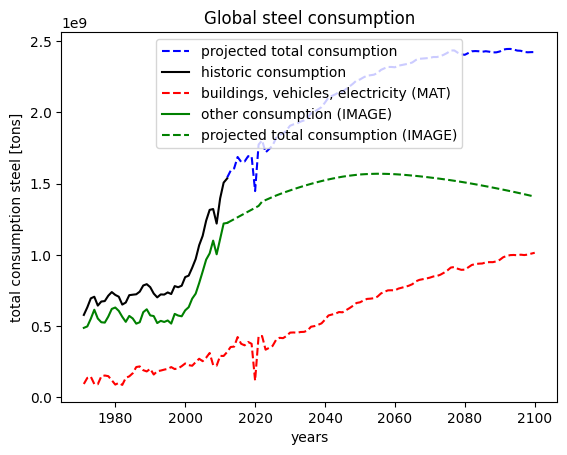

In [17]:
fig, ax = plt.subplots()             # Create a figure containing a single Axes.

ax.plot(steel.projection_per_region_total.sum(axis = 1) + steel.image_mat_data.sum(axis = 1).loc[2012:], 
        linestyle = '--', color = 'blue', label = 'projected total consumption')
ax.plot(steel.historic_consumption_data.sum(axis = 1),
        linestyle = '-', color = 'black', label = 'historic consumption')  

ax.plot(steel.image_mat_data.sum(axis = 1).loc[1971:],
        linestyle = '--', color = 'red', label = 'buildings, vehicles, electricity (MAT)')
ax.plot(steel.historic_other_fraction_consumption.sum(axis = 1),
        linestyle = '-', color = 'green', label = 'other consumption (IMAGE)')

ax.plot(steel.projection_per_region_total.loc[2012: ].sum(axis = 1),
        linestyle = '--', color = 'green', label = 'projected total consumption (IMAGE)')

ax.set_ylabel("total consumption steel [tons]")
ax.set_xlabel("years") 
ax.title.set_text("Global steel consumption")
ax.legend(loc = 'upper center')

In [18]:
steel.adjust_alpha_and_project(all_regions_list_class[:-1], 
                               start_year_adjust=2050, 
                               end_year_adjust=2100, 
                               min_alpha=None)

<Axes: >

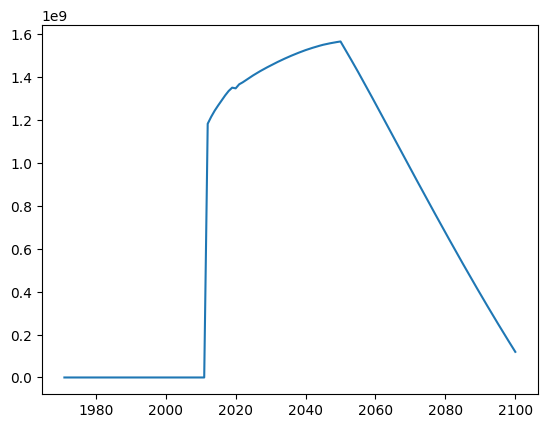

In [19]:
steel.projection_per_region_adapted_alpha.sum(axis = 1).plot()